# 1D CNN-A — Visualise: Heatmap Strip

Runs the full data pipeline and renders `N_SAMPLE` windows as a **heatmap strip** —
one row per window, each row is the 64 × 14 feature matrix flattened to 896 pixels wide.

Vertical lines mark feature-channel boundaries. Horizontal drift in brightness
across the strip shows how market character changes over time.

## 1. Imports

In [27]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # macOS: prevents libiomp/libomp conflict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from config import Config
from data import (
    load_bars, clean_data, add_features, drop_feature_nans,
    scale_features, make_windows, filter_gap_windows,
)
from visualise import prepare_sample, draw_heatmap

print(f"PyTorch {torch.__version__} | device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch 2.2.2 | device: cpu


## 2. Config

In [28]:
from config import Config

cfg = Config()

# ── Override defaults here before running the rest of the notebook ────────────
# cfg.MAX_BARS       = None   # load all bars (~552k)
# cfg.EPOCHS         = 30     # full training run
# cfg.N_CLUSTERS     = 12     # try more/fewer clusters
# cfg.LATENT_DIM     = 64     # larger latent space
# cfg.N_SAMPLE       = 5_000  # render more windows in Section 9

# Expose all config fields as module-level names so every downstream cell
# can use SYMBOL, WINDOW_SIZE, LR, feature_cols, DEVICE, etc. unchanged.
globals().update(vars(cfg))

print(f"Symbol={SYMBOL}  Timeframe={TIMEFRAME}  {START_DATE} → {END_DATE}")
print("Using device:", DEVICE)

Symbol=TSLA  Timeframe=1Min  2017-01-01 → 2026-06-11
Using device: cpu


## 3. Fetch Data from Alpaca API
Calls the local `alpaca_api` FastAPI service (must be running: `uv run main.py`).
Fetches TSLA 1-minute bars and saves to both DB and CSV.

In [29]:
if FETCH_DATA:
    import httpx  # only needed when FETCH_DATA = True
    params = {
        "symbols": SYMBOL,
        "timeframe": TIMEFRAME,
        "start": START_DATE,
        "end": END_DATE,
        "save_to": "db,csv",
    }
    with httpx.Client(timeout=None) as client:
        r = client.get(f"{API_BASE}/bars", params=params)
        r.raise_for_status()
        result = r.json()
    bars = result.get("data", {}).get("bars", {}).get(SYMBOL, [])
    print(f"Fetched {len(bars)} bars for {SYMBOL}")
    print("Saved:", result.get("saved"))
else:
    print("FETCH_DATA=False — skipping. Set True in Config to re-pull.")

FETCH_DATA=False — skipping. Set True in Config to re-pull.


## 4. Load Data

In [30]:
# Load raw OHLCV bars from the CSV file.
df = load_bars(DATA_DIR, SYMBOL, TIMEFRAME, MAX_BARS)

Loaded 2,000 bars  |  2020-07-27 13:30:00+00:00 → 2020-08-10 17:55:00+00:00  |  MAX_BARS=2,000


Check for:

Duplicate timestamps
Missing timestamps (gaps)
NaNs
Infinite values
Bad OHLC relationships (high < low, etc.)

Typical checks:

In [31]:
# Remove duplicate timestamps and rows with missing values.
df = clean_data(df)

clean_data: removed 0 rows  →  2,000 remaining


## 5. Verify Time Continuity
A CNN assumes a consistent sequence.

Look for:

missing bars
duplicate bars
irregular spacing

If you're using 1-minute candles, every row should be exactly 1 minutes apart.

In [32]:
delta = df["timestamp"].diff()
dt = pd.to_timedelta(delta).dt.total_seconds()
print("Average time delta (seconds):", dt.mean())
print("Time delta distribution (seconds):")
print(dt.describe())

Average time delta (seconds): 613.0565282641321
Time delta distribution (seconds):
count      1999.000000
mean        613.056528
std        8435.323022
min          60.000000
25%          60.000000
50%          60.000000
75%         120.000000
max      235860.000000
Name: timestamp, dtype: float64


## 6. Add Features

In [33]:
# Calculate 14 technical indicator columns (EMAs, MACD, candle shape, returns, volume ratio).
df = add_features(df)

add_features: appended 14 columns  →  21 total columns


## 6. Remove Initial NaNs

Feature engineering creates NaNs.

In [34]:
# Drop the warm-up rows where EMAs and rolling means don't have enough history yet.
df = drop_feature_nans(df)

drop_feature_nans: removed 19 warm-up rows  →  1,981 remaining


## 7. Scale Features

This is critical.

CNNs train poorly on:

close = 45000
volume = 10000000
return = 0.001

all mixed together.

StandardScaler

Most common:

In [35]:
# Normalise every feature column so they all sit in a similar numeric range.
# RobustScaler uses the median and IQR — better than mean/std for financial data with outliers.
df, scaler = scale_features(df, feature_cols)

scale_features: 14 columns normalised with RobustScaler


## 8. Create Fixed-Length Windows

A CNN does not ingest an entire dataframe.

It ingests samples.

In [36]:
# Slice the time series into overlapping WINDOW_SIZE-bar windows.
# Each window is one training sample for the CNN.
X_raw = make_windows(df, feature_cols, WINDOW_SIZE)
n_features = len(feature_cols)

make_windows: 1,918 windows of shape (64 bars × 14 features)


## 11. Filter Gap Windows
A window that spans an overnight or weekend gap mixes pre-gap and post-gap bars — the CNN would learn noise, not patterns. Any window whose 64-bar span crosses a gap > 5 minutes is dropped.

In [37]:
# Remove windows that span overnight or weekend gaps.
# Such windows would teach the model noise rather than real patterns.
X_clean, valid_mask = filter_gap_windows(X_raw, df, WINDOW_SIZE)

filter_gap_windows: 128 gaps found  |  removed 1,593 windows  |  325 clean windows remain


## 9. Visualise Windows as Greyscale Tiles

Before training, it's worth seeing what the windowed data actually *looks like*.
Each of the 156,781 clean windows is a 64-bar × 14-feature matrix of scaled
floats. Rendering them as greyscale images (bright = high value, dark = low)
lets us visually inspect the dataset for structure, gaps, outliers, and feature
behaviour at a scale no table or line-chart can match.

Three views are provided — all use the same global [0 → 255] normalisation so
brightness is directly comparable across windows and across views:

| View | What you see | Best for |
|------|-------------|----------|
| A — Contact sheet | Each window at full 64×14 px resolution, tiled in a grid | Inspecting individual window texture and feature patterns |
| B — Heatmap strip | Each window flattened to one row, all windows stacked vertically | Spotting dataset-wide trends, session rhythms, and drift over time |
| C — Thumbnail grid | Each window compressed to 10×10 px, tiled densely | Getting a high-level overview of brightness/contrast across the whole sample |

Adjust `N_SAMPLE` in the setup cell below to control how many windows are rendered.

In [38]:
# Take the first N_SAMPLE windows and convert pixel values to uint8 [0–255].
# Percentile clipping (p2/p98) prevents outliers from washing out the image.
sample_u8, N_SAMPLE, lo, hi = prepare_sample(X_clean, N_SAMPLE)

prepare_sample: 325 windows  |  p2=-1.753  p98=1.857  →  [0, 255]


### View B — Heatmap Strip (one row per window, 896 px wide)

Each 64×14 window is **flattened into a single row of 896 values** (64 bars ×
14 features, concatenated left-to-right). All `N_SAMPLE` rows are stacked
vertically to form a 2D heatmap where:

- **X-axis (horizontal):** position within a window. The 896 columns cycle
  through all 14 features for bar 0, then all 14 for bar 1, and so on.
  Red dividers mark the boundary between each feature channel.
- **Y-axis (vertical):** window index — top = earliest window, bottom = latest.

**What to look for:**
- **Horizontal bands of consistent colour**: a feature at a sustained extreme
  across many consecutive windows — e.g. a trending period where EMA values
  are persistently bright or dark.
- **Vertical bright/dark stripes**: a feature that is consistently extreme
  *within* its column across all windows — `volume_ratio` often stands out here.
- **Gradual brightness drift** top → bottom: the dataset evolving over time —
  price levels, volatility regimes, or micro-structure changes.
- **Sharp horizontal edges**: abrupt regime changes (earnings, macro events)
  where the data character shifts suddenly.
- **Uniform mid-grey regions**: quiet, low-information periods.

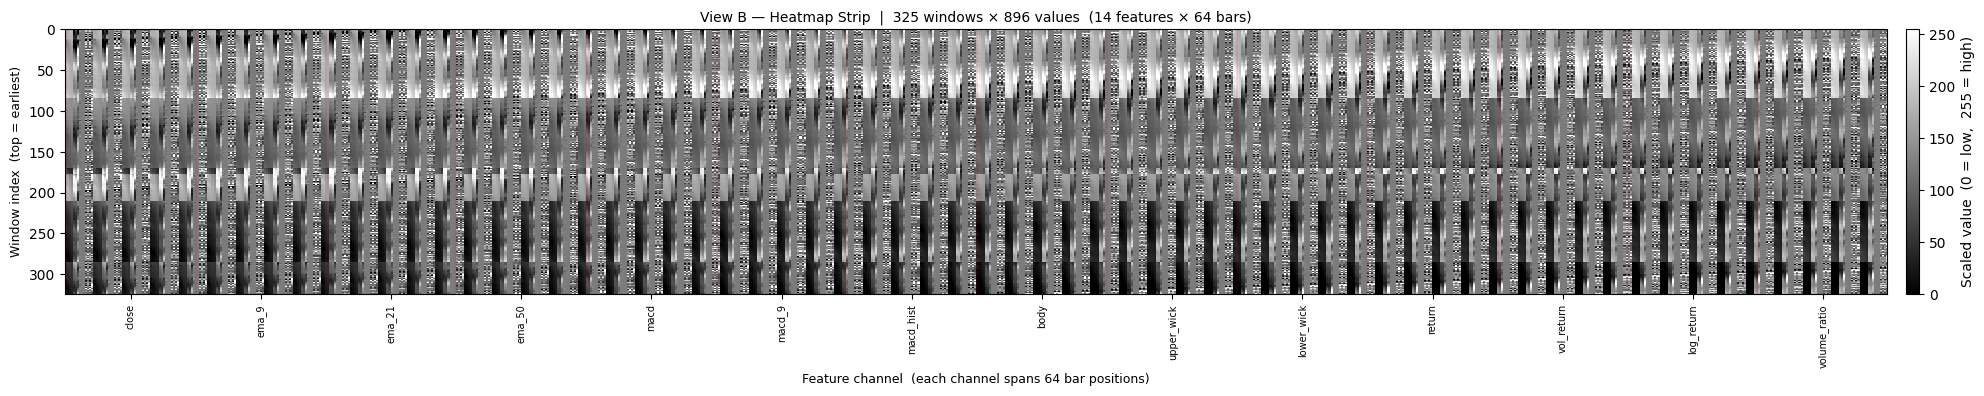

In [39]:
# Draw View B: all windows stacked into one wide heatmap strip.
fig = draw_heatmap(sample_u8, feature_cols, WINDOW_SIZE)
plt.show()